In [15]:
import pandas as pd
import numpy as np

np.random.seed(42)

df = pd.DataFrame({
    "customer_id": range(1, 101),
    "age": np.random.randint(20, 60, 100),
    "transactions": np.random.randint(1, 20, 100),
    "fraud": np.random.randint(0, 2, 100)
})

df.head()

,customer_id,age,transactions,fraud
0,1,58,16,1
1,2,48,5,1
2,3,34,3,0
3,4,27,12,1
4,5,40,8,1


In [16]:
df.to_parquet("data.parquet", index=False)
print("Data saved successfully")

Data saved successfully


In [17]:
import pandas as pd

df = pd.read_parquet("data.parquet")
df.head()

,customer_id,age,transactions,fraud
0,1,58,16,1
1,2,48,5,1
2,3,34,3,0
3,4,27,12,1
4,5,40,8,1


In [18]:
!feast init feature_repo


Creating a new Feast repository in C:\Users\user\feature_repo\feature_repo.



In [19]:
import os
os.getcwd()

'C:\\Users\\user\\feature_repo'

In [5]:
import os
os.chdir("feature_repo")

In [8]:
import shutil
shutil.copy("../data.parquet", "data.parquet")

'data.parquet'

In [20]:
%%writefile feature_repo.py

from feast import Entity, FeatureView, Field, FileSource
from feast.types import Int64
from datetime import timedelta

# Entity (primary key)
customer = Entity(name="customer_id", join_keys=["customer_id"])

# Data source
data_source = FileSource(
    path="data.parquet",
    timestamp_field=None,
)

# Feature View
customer_features = FeatureView(
    name="customer_features",
    entities=[customer],
    ttl=timedelta(days=1),
    schema=[
        Field(name="age", dtype=Int64),
        Field(name="transactions", dtype=Int64),
    ],
    source=data_source,
)

Writing feature_repo.py


In [21]:
!feast apply

Applying changes for project feature_repo


C:\Users\user\feature_repo\feature_definitions.py:34: DeprecationWarning: invalid escape sequence '\d'
  path="data\driver_stats.parquet",
C:\Users\user\feature_repo\feature_definitions.py:27: DeprecationWarning: Entity value_type will be mandatory in the next release. Please specify a value_type for entity 'driver'.
  driver = Entity(name="driver", join_keys=["driver_id"])
C:\Users\user\feature_repo\feature_repo.py:7: DeprecationWarning: Entity value_type will be mandatory in the next release. Please specify a value_type for entity 'customer_id'.
  customer = Entity(name="customer_id", join_keys=["customer_id"])
C:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\feast\feature_store.py:677: RuntimeWarning: On demand feature view is an experimental feature. This API is stable, but the functionality does not scale well for offline retrieval
  warnings.warn(
Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen ru

In [12]:
from feast import FeatureStore

store = FeatureStore(repo_path=".")

features = store.get_online_features(
    features=[
        "customer_features:age",
        "customer_features:transactions"
    ],
    entity_rows=[{"customer_id": 1}]
).to_dict()

features

FileNotFoundError: [Errno 2] No such file or directory: 'feature_store.yaml'

In [13]:
ls ~/.mlrun/feature-store.yaml

Invalid switch - ".mlrun".


In [22]:
import pandas as pd
import numpy as np

np.random.seed(42)

df = pd.DataFrame({
    "customer_id": range(1, 101),
    "age": np.random.randint(20, 60, 100),
    "transactions": np.random.randint(1, 20, 100),
    "fraud": np.random.randint(0, 2, 100),
    "event_timestamp": pd.Timestamp.now()
})

df.head()

,customer_id,age,transactions,fraud,event_timestamp
0,1,58,16,1,2026-03-29 10:44:37.946217
1,2,48,5,1,2026-03-29 10:44:37.946217
2,3,34,3,0,2026-03-29 10:44:37.946217
3,4,27,12,1,2026-03-29 10:44:37.946217
4,5,40,8,1,2026-03-29 10:44:37.946217


In [23]:
df.to_parquet("data.parquet", index=False)

In [24]:
import shutil
shutil.copy("../data.parquet", "data.parquet")

'data.parquet'

In [35]:
from feast import Entity, FeatureView, Field, FileSource
from feast.types import Int64
from datetime import timedelta

# Entity
customer = Entity(
    name="customer_id",
    join_keys=["customer_id"],
    value_type=Int64
)

# Data source
data_source = FileSource(
    path="data.parquet",
    timestamp_field="event_timestamp",
)

# Feature View
customer_features = FeatureView(
    name="customer_features",
    entities=[customer],
    ttl=timedelta(days=1),
    schema=[
        Field(name="age", dtype=Int64),
        Field(name="transactions", dtype=Int64),
    ],
    source=data_source,
)

TypeCheckError: argument "value_type" (feast.types.PrimitiveFeastType) did not match any element in the union:
  feast.value_type.ValueType: is not an instance of feast.value_type.ValueType
  NoneType: is not an instance of NoneType

In [43]:
from feast import Entity, FeatureView, Field, FileSource
from feast.types import Int64
from datetime import timedelta

# Entity (simplified)
customer = Entity(
    name="customer_id",
    join_keys=["customer_id"],
    value_type=Int64
)

# Data source
data_source = FileSource(
    path="data.parquet",
    timestamp_field="event_timestamp",
)

# Feature View
customer_features = FeatureView(
    name="customer_features",
    entities=[customer],
    ttl=timedelta(days=1),
    schema=[
        Field(name="age", dtype=Int64),
        Field(name="transactions", dtype=Int64),
    ],
    source=data_source,
)

TypeCheckError: argument "value_type" (feast.types.PrimitiveFeastType) did not match any element in the union:
  feast.value_type.ValueType: is not an instance of feast.value_type.ValueType
  NoneType: is not an instance of NoneType

In [38]:
!feast apply

Applying changes for project feature_repo


C:\Users\user\feature_repo\feature_definitions.py:27: DeprecationWarning: Entity value_type will be mandatory in the next release. Please specify a value_type for entity 'driver'.
  driver = Entity(name="driver", join_keys=["driver_id"])
C:\Users\user\feature_repo\feature_repo.py:7: DeprecationWarning: Entity value_type will be mandatory in the next release. Please specify a value_type for entity 'customer_id'.
  customer = Entity(name="customer_id", join_keys=["customer_id"])
C:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\feast\feature_store.py:677: RuntimeWarning: On demand feature view is an experimental feature. This API is stable, but the functionality does not scale well for offline retrieval
  warnings.warn(
Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\user\AppData\Local\Programs\Python\Python311\Scripts\feast.exe\__main__.py", line 6, in <modu

In [39]:
import os
os.remove("feature_definitions.py")
print("Deleted feature_definitions.py")

Deleted feature_definitions.py


In [40]:
os.listdir()

['.ipynb_checkpoints',
 'data',
 'data.parquet',
 'feature_repo.py',
 'feature_store.yaml',
 'test_workflow.py',
 '__init__.py',
 '__pycache__']

In [42]:
!feast apply

No project found in the repository. Using project name feature_repo defined in feature_store.yaml
Applying changes for project feature_repo
Created project feature_repo
Created entity customer_id
Created feature view customer_features

Created sqlite table feature_repo_customer_features



C:\Users\user\feature_repo\feature_repo.py:7: DeprecationWarning: Entity value_type will be mandatory in the next release. Please specify a value_type for entity 'customer_id'.
  customer = Entity(name="customer_id", join_keys=["customer_id"])


In [44]:
import pandas as pd

df = pd.read_parquet("data.parquet")
df.head()

,customer_id,age,transactions,fraud
0,1,58,16,1
1,2,48,5,1
2,3,34,3,0
3,4,27,12,1
4,5,40,8,1


In [45]:
cd ..

C:\Users\user


In [46]:
import pandas as pd

df = pd.read_parquet("data.parquet")
df.head()

,customer_id,age,transactions,fraud
0,1,58,16,1
1,2,48,5,1
2,3,34,3,0
3,4,27,12,1
4,5,40,8,1


In [47]:
cd feature_repo

C:\Users\user\feature_repo


In [48]:
import pandas as pd
import numpy as np

np.random.seed(42)

df = pd.DataFrame({
    "customer_id": range(1, 101),
    "age": np.random.randint(20, 60, 100),
    "transactions": np.random.randint(1, 20, 100),
    "fraud": np.random.randint(0, 2, 100),
    "event_timestamp": pd.Timestamp.now()   # 👈 IMPORTANT
})

df.to_parquet("data.parquet", index=False)

print(df.columns)

Index(['customer_id', 'age', 'transactions', 'fraud', 'event_timestamp'], dtype='object')


In [49]:
import pandas as pd

df = pd.read_parquet("data.parquet")
df.head()

,customer_id,age,transactions,fraud,event_timestamp
0,1,58,16,1,2026-03-29 11:14:15.215843
1,2,48,5,1,2026-03-29 11:14:15.215843
2,3,34,3,0,2026-03-29 11:14:15.215843
3,4,27,12,1,2026-03-29 11:14:15.215843
4,5,40,8,1,2026-03-29 11:14:15.215843


In [50]:
!feast apply

No project found in the repository. Using project name feature_repo defined in feature_store.yaml
Applying changes for project feature_repo
No changes to registry
No changes to infrastructure


C:\Users\user\feature_repo\feature_repo.py:7: DeprecationWarning: Entity value_type will be mandatory in the next release. Please specify a value_type for entity 'customer_id'.
  customer = Entity(name="customer_id", join_keys=["customer_id"])


In [53]:
import pandas as pd
df = pd.read_parquet("data.parquet")
print(df.columns)

Index(['customer_id', 'age', 'transactions', 'fraud', 'event_timestamp'], dtype='object')


In [57]:
from feast import FeatureStore

store = FeatureStore(repo_path="C:/Users/user/feature_repo")

features = store.get_online_features(
    features=[
        "customer_features:age",
        "customer_features:transactions"
    ],
    entity_rows=[{"customer_id": 1}]
).to_dict()

features

{'customer_id': [1], 'transactions': [16], 'age': [58]}

In [56]:
from datetime import datetime, timedelta

!feast materialize-incremental {datetime.now().isoformat()}

Materializing 1 feature views to 2026-03-29 11:21:07+00:00 into the sqlite online store.

customer_features from 2026-03-28 05:51:23+00:00 to 2026-03-29 11:21:07+00:00:


In [59]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Load data
df = pd.read_parquet("C:/Users/user/feature_repo/data.parquet")

# Features + target
X = df[["age", "transactions"]]
y = df["fraud"]

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Train model
model = RandomForestClassifier()
model.fit(X_train, y_train)

# Accuracy
accuracy = model.score(X_test, y_test)
print("Accuracy:", accuracy)

Accuracy: 0.5


In [60]:
!mlflow ui

Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\user\AppData\Local\Programs\Python\Python311\Scripts\mlflow.exe\__main__.py", line 6, in <module>
  File "C:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\click\core.py", line 1462, in __call__
    return self.main(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\click\core.py", line 1383, in main
    rv = self.invoke(ctx)
         ^^^^^^^^^^^^^^^^
  File "C:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\click\core.py", line 1850, in invoke
    return _process_result(sub_ctx.command.invoke(sub_ctx))
                           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\click\core.py", line 1246, in invoke
    return ctx.invoke(self.cal

In [61]:
!pip install prometheus_flask_exporter

In [1]:
!mlflow ui

^C


In [ ]:
import mlflow

mlflow.set_tracking_uri("file:///C:/Users/user/mlruns")
mlflow.set_experiment("demo_experiment")

In [4]:
print(mlflow.get_tracking_uri())

file:///C:/Users/user/mlruns


In [5]:
import mlflow.sklearn

with mlflow.start_run():
    mlflow.log_param("model_type", "RandomForest")
    mlflow.log_metric("accuracy", accuracy)
    mlflow.sklearn.log_model(model, "model")

NameError: name 'accuracy' is not defined

In [2]:
!mlflow ui --backend-store-uri "file:///C:/Users/user/mlruns"

^C


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Load data
df = pd.read_parquet("C:/Users/user/feature_repo/data.parquet")

# Features + target
X = df[["age", "transactions"]]
y = df["fraud"]

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Train model
model = RandomForestClassifier()
model.fit(X_train, y_train)

# Accuracy
accuracy = model.score(X_test, y_test)
print("Accuracy:", accuracy)

In [8]:
import mlflow
import mlflow.sklearn

mlflow.set_tracking_uri("file:///C:/Users/user/mlruns")
mlflow.set_experiment("demo_experiment")

with mlflow.start_run():
    mlflow.log_param("model_type", "RandomForest")
    mlflow.log_metric("accuracy", accuracy)
    mlflow.sklearn.log_model(model, name="model")

print("Run logged successfully")

2026/03/29 11:56:39 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Run logged successfully


In [ ]:
!mlflow ui --backend-store-uri "file:///C:/Users/user/mlruns"

In [1]:
import pandas as pd
import numpy as np

# Simulate drift (higher values)
df_drift = pd.DataFrame({
    "customer_id": range(101, 201),
    "age": np.random.randint(50, 80, 100),             # older population
    "transactions": np.random.randint(50, 200, 100),   # big shift
    "fraud": np.random.randint(0, 2, 100),
    "event_timestamp": pd.Timestamp.now()
})

df_drift.head()

,customer_id,age,transactions,fraud,event_timestamp
0,101,67,97,0,2026-03-29 12:30:40.111200
1,102,74,154,0,2026-03-29 12:30:40.111200
2,103,61,149,1,2026-03-29 12:30:40.111200
3,104,69,115,0,2026-03-29 12:30:40.111200
4,105,58,110,0,2026-03-29 12:30:40.111200


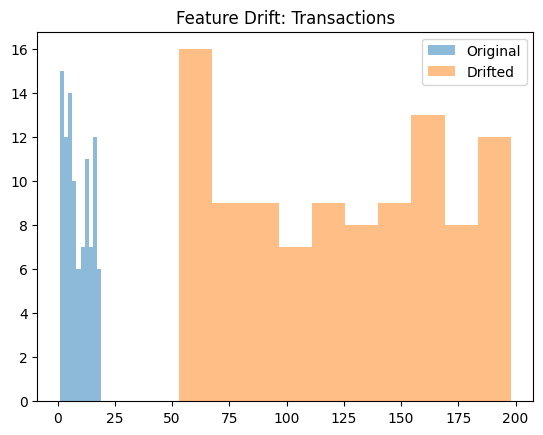

In [2]:
import matplotlib.pyplot as plt

# Load original data
df_orig = pd.read_parquet("data.parquet")

plt.hist(df_orig["transactions"], alpha=0.5, label="Original")
plt.hist(df_drift["transactions"], alpha=0.5, label="Drifted")
plt.legend()
plt.title("Feature Drift: Transactions")
plt.show()

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

df = pd.read_parquet("data.parquet")

X = df[["age", "transactions"]]
y = df["fraud"]

X_train, X_test, y_train, y_test = train_test_split(X, y)

model = RandomForestClassifier()
model.fit(X_train, y_train)

accuracy = model.score(X_test, y_test)
print("Accuracy:", accuracy)

Accuracy: 0.64


In [6]:
X_drift = df_drift[["age", "transactions"]]
y_drift = df_drift["fraud"]

drift_accuracy = model.score(X_drift, y_drift)
print("Accuracy on drifted data:", drift_accuracy)

Accuracy on drifted data: 0.43


In [14]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_drift)

drift_accuracy = accuracy_score(y_drift, y_pred)

print("Drift Accuracy:", drift_accuracy)

Drift Accuracy: 0.43


In [18]:
import mlflow

mlflow.set_experiment("demo_experiment")

with mlflow.start_run() as run:
    print("Run ID:", run.info.run_id)
    mlflow.log_metric("drift_accuracy", drift_accuracy)
    mlflow.log_param("scenario", "feature_drift")
print("MLflow logging done")

Run ID: 92f1dea64bdb42ad89ff4efb4467548c
MLflow logging done


In [11]:
drift_accuracy = model.predict(X_drift)

print(drift_accuracy[:5])

[1 1 1 1 1]


In [20]:
import mlflow.pyfunc

model = mlflow.pyfunc.load_model("models:/FraudModel@champion")

In [ ]:
!mlflow models serve -m "models:/FraudModel@champion" -p 5001 --env-manager=local

In [ ]:
from feast import FeatureStore

# Get features
store = FeatureStore(repo_path="feature_repo")

features = store.get_online_features(
    features=[
        "customer_features:age",
        "customer_features:transactions"
    ],
    entity_rows=[{"customer_id": 1}]
).to_dict()

# Prepare input
import pandas as pd

input_df = pd.DataFrame({
    "age": features["age"],
    "transactions": features["transactions"]
})

# Predict
prediction = model.predict(input_df)
print("Prediction:", prediction)

In [26]:
import requests

data = {
    "dataframe_records": [
        {"age": 35, "transactions": 10}
    ]
}

response = requests.post(
    "http://127.0.0.1:5001/invocations",
    json=data
)

print(response.json())

{'predictions': [1]}


In [ ]:
!mlflow ui --backend-store-uri "file:///C:/Users/user/mlruns"